In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [2]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
for col in numeric_features:
    # 填充缺失值（使用中位数而不是均值，对异常值更鲁棒）
    if all_features[col].isnull().any():
        col_median = all_features[col].median()
        all_features[col] = all_features[col].fillna(col_median)
    # 检查是否需要log变换（处理偏态分布）
    if col not in ['MSSubClass', 'OverallQual', 'OverallCond', 'YearBuilt', 
                   'YearRemodAdd', 'MoSold', 'YrSold']:
        if all_features[col].skew() > 1:
            all_features[col] = np.log1p(all_features[col] - all_features[col].min() + 1)
    # 标准化
    col_mean = all_features[col].mean()
    col_std = all_features[col].std()
    if col_std > 0:
        all_features[col] = (all_features[col] - col_mean) / col_std
    else:
        all_features[col] = 0
# 处理类别特征
categorical_features = all_features.dtypes[all_features.dtypes == 'object'].index
all_features = pd.get_dummies(all_features, columns=categorical_features, dummy_na=True)
# 确保所有数据都是数值类型
all_features = all_features.astype(float)
all_features.shape

(2919, 330)

In [3]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
# 对标签进行对数变换
train_labels_original = train_data.SalePrice.values
train_labels_log = np.log1p(train_labels_original)
train_labels = torch.tensor(train_labels_log.reshape(-1, 1), dtype=torch.float32)


In [44]:
input_dim = train_features.shape[1]
hidden_dim1 = 256
hidden_dim2 = 128
hidden_dim3 = 64
output_dim = 1
batch_size = 64
learning_rate = 0.001
num_epochs = 200
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [45]:
class FixedMLP(nn.Module):
    def __init__(self, input_dim):
        super(FixedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model = FixedMLP(train_features.shape[1]).to(device)
print(f"\n模型参数数量: {sum(p.numel() for p in model.parameters())}")


模型参数数量: 126849


In [46]:
dataset = TensorDataset(train_features, train_labels)

# 使用固定随机种子确保可重复性
torch.manual_seed(42)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

# 正确的划分方式
train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [47]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
# scheduler：每25个epoch学习率减半
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)

In [48]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
    
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * features.size(0)
    
    return total_loss / len(loader.dataset)

In [49]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()
    # 保存最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    if (epoch + 1) % 25 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}, '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch [25/200], Train Loss: 0.037750, Val Loss: 0.019623, LR: 0.000500
Epoch [50/200], Train Loss: 0.018835, Val Loss: 0.018508, LR: 0.000250
Epoch [75/200], Train Loss: 0.014448, Val Loss: 0.020217, LR: 0.000125
Epoch [100/200], Train Loss: 0.010353, Val Loss: 0.018286, LR: 0.000063
Epoch [125/200], Train Loss: 0.011557, Val Loss: 0.017831, LR: 0.000031
Epoch [150/200], Train Loss: 0.010194, Val Loss: 0.016242, LR: 0.000016
Epoch [175/200], Train Loss: 0.011849, Val Loss: 0.015482, LR: 0.000008
Epoch [200/200], Train Loss: 0.011314, Val Loss: 0.017051, LR: 0.000004


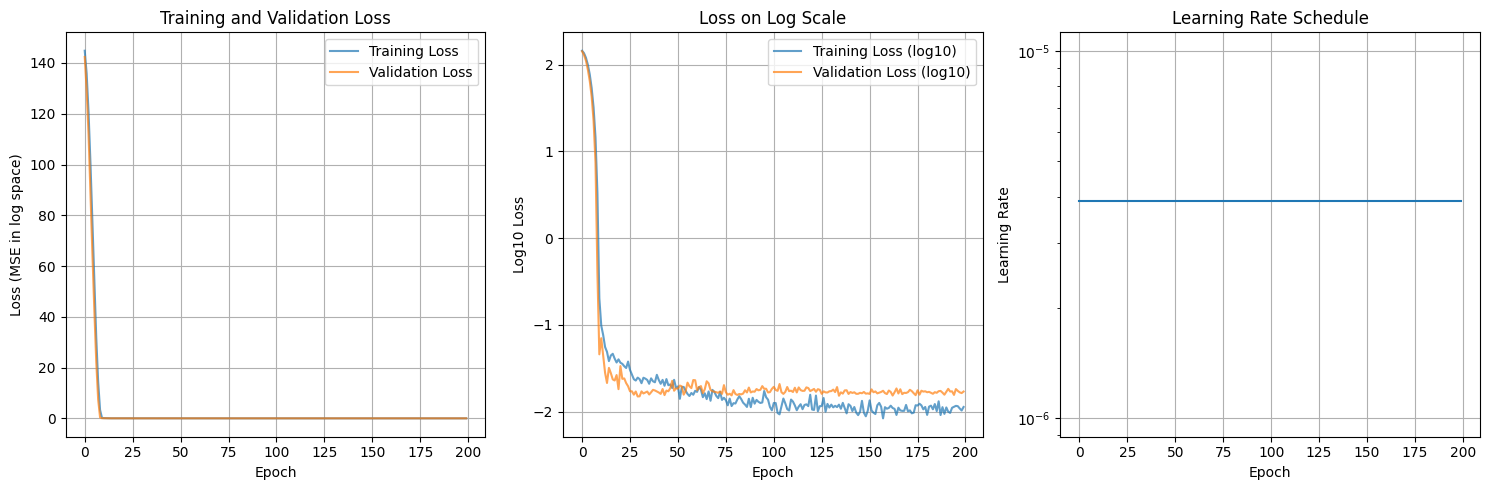

In [51]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE in log space)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(np.log10(train_losses), label='Training Loss (log10)', alpha=0.7)
plt.plot(np.log10(val_losses), label='Validation Loss (log10)', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Log10 Loss')
plt.title('Loss on Log Scale')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
# 学习率变化
lrs = [optimizer.param_groups[0]['lr'] for _ in range(len(train_losses))]
plt.plot(lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.yscale('log')
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
def predict(model, features, device):
    model.eval()
    with torch.no_grad():
        features = features.to(device)
        predictions = model(features)
    return predictions.cpu().numpy()

# 预测
test_predictions_log = predict(model, test_features, device)
test_predictions = np.expm1(test_predictions_log)

train_predictions_log = predict(model, train_features, device)
train_predictions = np.expm1(train_predictions_log)

# 计算训练集上的指标
train_actual = train_data.SalePrice.values
train_pred = train_predictions.flatten()

# 计算多个指标
train_rmse = np.sqrt(np.mean((train_pred - train_actual) ** 2))
train_mae = np.mean(np.abs(train_pred - train_actual))
train_mape = np.mean(np.abs((train_actual - train_pred) / train_actual)) * 100

print("训练集评估指标:")
print(f"RMSE: {train_rmse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"MAPE: {train_mape:.2f}%")
test_predictions_log = predict(model, test_features, device)
test_predictions = np.expm1(test_predictions_log).flatten()
train_min, train_max, train_mean = train_actual.min(), train_actual.max(), train_actual.mean()
print(f"\n与训练集对比:")
print(f"  训练集范围: [${train_min:.2f}, ${train_max:.2f}]")
print(f"  测试集范围: [${test_predictions.min():.2f}, ${test_predictions.max():.2f}]")
print(f"  均值差异: ${test_predictions.mean() - train_mean:.2f} ({((test_predictions.mean()/train_mean)-1)*100:.1f}%)")
print(f"  预测值变异系数 : {test_predictions.std()/test_predictions.mean():.3f}")
print(f"  训练集变异系数: {train_actual.std()/train_mean:.3f}")

训练集评估指标:
RMSE: 16413.42
MAE: 9641.94
MAPE: 4.87%

与训练集对比:
  训练集范围: [$34900.00, $755000.00]
  测试集范围: [$31218.25, $589302.38]
  均值差异: $-8021.68 (-4.4%)
  预测值变异系数 : 0.405
  训练集变异系数: 0.439


In [52]:
submission = pd.DataFrame({
    'Id': test_data.Id,
    'SalePrice': test_predictions.flatten()
})
submission['SalePrice'] = submission['SalePrice'].clip(lower=0, upper=1e6)
submission.to_csv('submission.csv', index=False)

print(f"提交文件已保存到 submission.csv")

提交文件已保存到 submission.csv


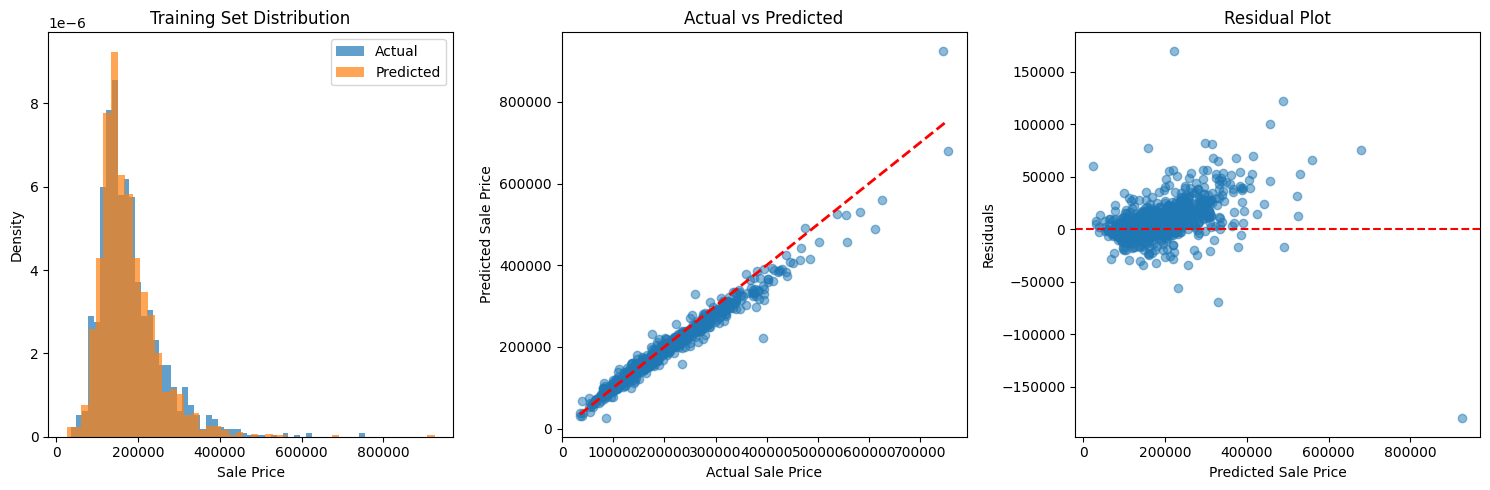

In [53]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_actual, bins=50, alpha=0.7, label='Actual', density=True)
plt.hist(train_pred, bins=50, alpha=0.7, label='Predicted', density=True)
plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.title('Training Set Distribution')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(train_actual, train_pred, alpha=0.5)
plt.plot([train_actual.min(), train_actual.max()], 
         [train_actual.min(), train_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted')

plt.subplot(1, 3, 3)
residuals = train_actual - train_pred
plt.scatter(train_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()